# Phishing URL Detector — Exploratory Data Analysis

**Day 2:** Now that the data loads cleanly, let's actually look at it.

Goals for today:
1. Visualize the class balance (phishing vs. legitimate)
2. Look at the distribution of a few interesting features
3. Compare how features differ between phishing and legitimate URLs
4. Find which features correlate most strongly with the label
5. Identify any obvious issues (constant columns, duplicates, leakage)

Why this matters: tomorrow we'll train models. The choices we make then —
which features to use, which model to pick, what to expect for accuracy —
all come from what we learn today.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Reproducibility — set a seed everywhere we use randomness
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports ok.")

Imports ok.


In [2]:
DATA_PATH = Path("../data/PhiUSIIL_Phishing_URL_Dataset.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")

Loaded 235,795 rows and 56 columns.


## 1. Class balance — visualized

We printed counts on Day 1. Let's see it as a chart.

**Why this matters:** if the dataset were 95% legitimate, a model that predicts
"legitimate" for everything would have 95% accuracy and be useless. Accuracy
is only meaningful in context of class balance.

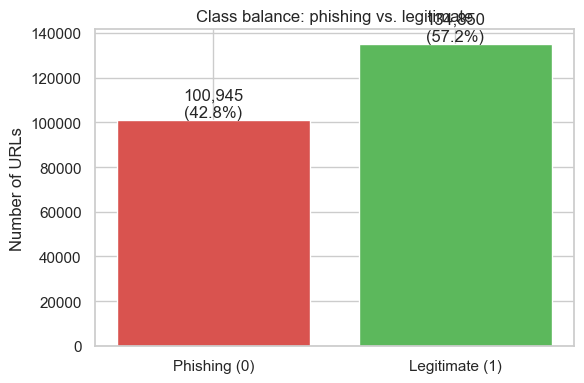

In [3]:
label_counts = df["label"].value_counts().sort_index()
labels = ["Phishing (0)", "Legitimate (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, label_counts.values, color=["#d9534f", "#5cb85c"])
ax.set_title("Class balance: phishing vs. legitimate")
ax.set_ylabel("Number of URLs")

# Annotate bars with counts and percentages
total = label_counts.sum()
for bar, count in zip(bars, label_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 2. Drop columns that aren't features

Looking at the columns, some are identifiers or raw strings, not numeric features
we can train on directly. Common ones in this dataset: `FILENAME`, `URL`,
`Domain`, `TLD`, `Title`. We'll set those aside for now.

We're also going to be careful about **data leakage** — features that wouldn't be
available in the real world at prediction time. If anything looks like it directly
encodes the label, we'll note it.

In [4]:
# Look at non-numeric columns — these are usually strings/identifiers
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:")
for col in non_numeric:
    sample = df[col].iloc[0]
    print(f"  {col}: {str(sample)[:60]}")

Non-numeric columns:
  FILENAME: 521848.txt
  URL: https://www.southbankmosaics.com
  Domain: www.southbankmosaics.com
  TLD: com
  Title: à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸‚à¹ˆà¸²à


In [5]:
# Build the working feature set: numeric columns only, minus the label
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove("label")

print(f"{len(feature_cols)} numeric features available for modeling.")
print("\nFirst 15 features:")
for col in feature_cols[:15]:
    print(f"  {col}")

50 numeric features available for modeling.

First 15 features:
  URLLength
  DomainLength
  IsDomainIP
  URLSimilarityIndex
  CharContinuationRate
  TLDLegitimateProb
  URLCharProb
  TLDLength
  NoOfSubDomain
  HasObfuscation
  NoOfObfuscatedChar
  ObfuscationRatio
  NoOfLettersInURL
  LetterRatioInURL
  NoOfDegitsInURL


## 3. Check for constant columns

A column with the same value for every row is useless to a model — drop it.
(Spoiler: there's usually at least one.)

In [6]:
constant_cols = [c for c in feature_cols if df[c].nunique() <= 1]
if constant_cols:
    print(f"Found {len(constant_cols)} constant column(s) — we'll drop these later:")
    for c in constant_cols:
        print(f"  {c}  (value: {df[c].iloc[0]})")
    # Remove from our working list
    feature_cols = [c for c in feature_cols if c not in constant_cols]
    print(f"\nFeatures remaining: {len(feature_cols)}")
else:
    print("No constant columns — good.")

No constant columns — good.


## 4. Check for duplicates

Duplicate rows can inflate accuracy artificially — the model 'memorizes' them
and sees them again in the test set.

In [7]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)")
if n_dup > 0:
    print("We'll deal with these in Day 3 when we split into train/test.")

Duplicate rows: 0 (0.00%)


## 5. Distributions of a few interesting features

Let's look at how phishing and legitimate URLs differ on a handful of features
you'd intuitively expect to matter:

- `URLLength` — phishing URLs are often longer (extra subdomains, encoded params)
- `NoOfSubDomain` — phishing sites pad with subdomains to look legit
- `IsHTTPS` — legitimate sites usually have HTTPS; some phishing does too
- `DomainLength` — long random-looking domains are suspicious

If a feature is in your CSV under a slightly different name, adjust below.
If a feature is missing, just skip it — the dataset has 50+ features and we
don't need all of them today.

In [8]:
# Candidate features to visualize. Filter to ones that actually exist in the data.
candidates = ["URLLength", "DomainLength", "NoOfSubDomain", "IsHTTPS"]
to_plot = [c for c in candidates if c in df.columns]

if not to_plot:
    print("None of the expected features were found. Print df.columns and pick 3-4 to plot.")
else:
    print(f"Plotting: {to_plot}")

Plotting: ['URLLength', 'DomainLength', 'NoOfSubDomain', 'IsHTTPS']


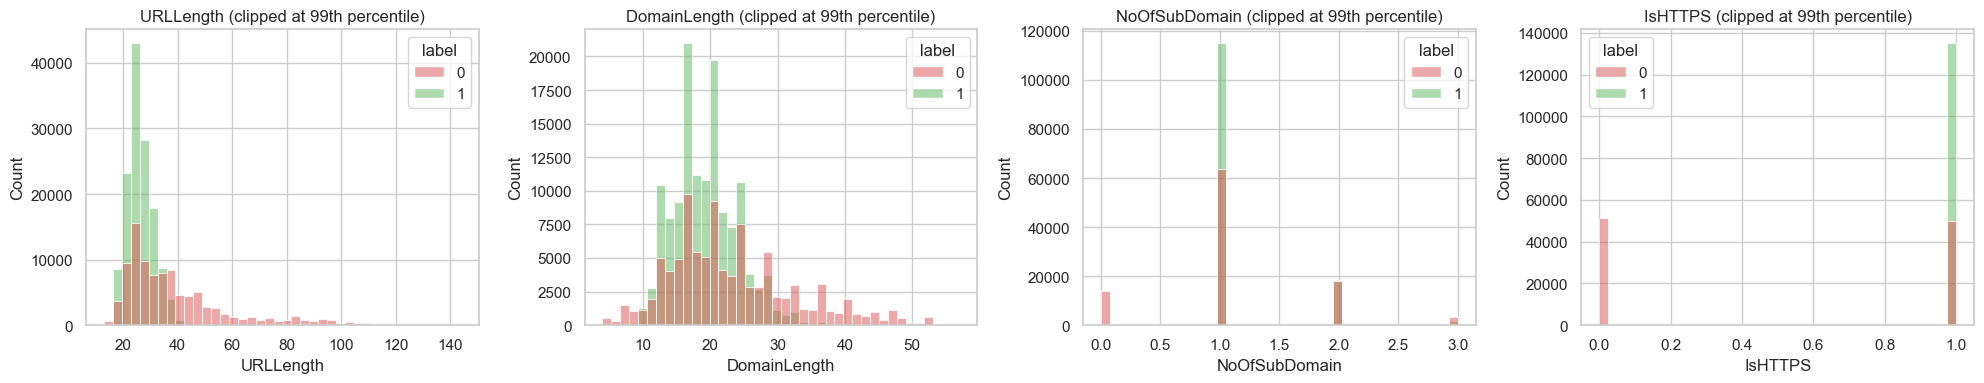

In [9]:
# Side-by-side histograms split by class for each feature
n = len(to_plot)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, to_plot):
    # For features with very long tails (like URL length), clip the x-axis to the 99th percentile
    # so the histogram is actually readable
    upper = df[col].quantile(0.99)
    lower = df[col].min()
    sns.histplot(
        data=df[df[col].between(lower, upper)],
        x=col,
        hue="label",
        bins=40,
        kde=False,
        ax=ax,
        palette={0: "#d9534f", 1: "#5cb85c"},
    )
    ax.set_title(f"{col} (clipped at 99th percentile)")

plt.tight_layout()
plt.show()

**What to look for in those plots:**

- Do the red (phishing) and green (legitimate) distributions overlap heavily, or are they clearly separated?
- Clear separation = the feature is predictive on its own.
- Heavy overlap = the model will need to combine this feature with others to use it.

Write a one-sentence observation for each plot in the Day 2 Summary at the bottom.

## 6. Group statistics — phishing vs. legitimate

A quick numeric way to see which features differ between the two classes:
compare the mean of each feature for phishing vs. legitimate.

In [10]:
group_means = df.groupby("label")[feature_cols].mean().T
group_means.columns = ["phishing_mean", "legitimate_mean"]

# Relative difference — how much bigger is the legitimate mean than the phishing one?
# (Adding a small epsilon to avoid divide-by-zero)
group_means["abs_diff"] = (group_means["legitimate_mean"] - group_means["phishing_mean"]).abs()
group_means = group_means.sort_values("abs_diff", ascending=False)

print("Top 10 features with the biggest mean difference between classes:")
group_means.head(10)

Top 10 features with the biggest mean difference between classes:


,phishing_mean,legitimate_mean,abs_diff
LargestLineLength,20021.448244,7375.919555,12645.528689
LineOfCode,65.730467,1947.491680,1881.761213
NoOfSelfRef,0.496032,113.410241,112.914209
NoOfExternalRef,1.128119,85.294601,84.166482
DomainTitleMatchScore,16.548205,75.270904,58.722698
URLTitleMatchScore,21.198164,75.270904,54.072739
URLSimilarityIndex,49.616973,100.000000,50.383027
NoOfImage,0.866492,44.946600,44.080108
URLLength,45.720293,26.228610,19.491684
NoOfJS,0.890336,17.732532,16.842196


**Warning sign:** if a feature has, say, mean = 1.0 for one class and mean = 0.0
for the other, that's *suspiciously* perfect. It could indicate **data leakage** —
a feature that wouldn't actually be available before classifying a URL in the real
world. We'll deal with this on Day 3.

## 7. Correlation with the label

Pearson correlation between each feature and the label. Values close to +1 or -1
mean strong linear relationship; close to 0 means none.

This is a rough first pass — non-linear relationships won't show up here. But
it's a useful quick scan.

In [11]:
correlations = df[feature_cols + ["label"]].corr()["label"].drop("label")
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

print("Top 15 features by absolute correlation with label:")
print(correlations_sorted.head(15).to_string())

Top 15 features by absolute correlation with label:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725


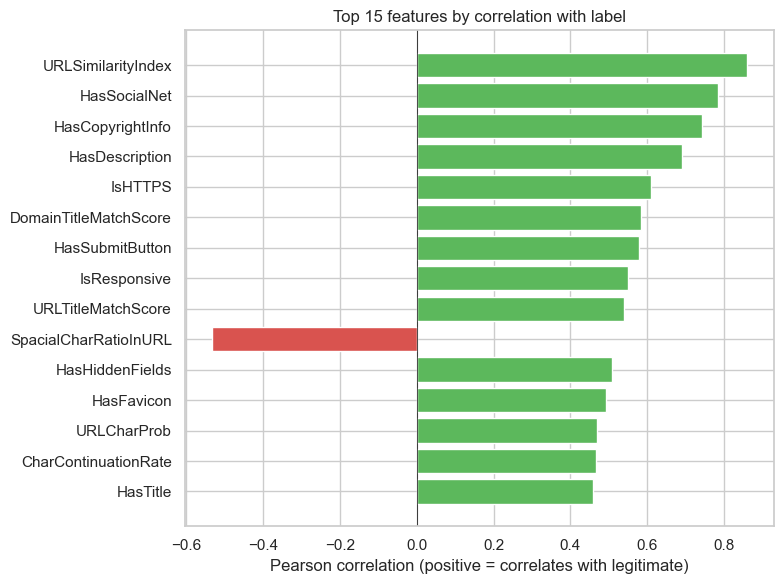

In [12]:
# Visualize the top 15
top15 = correlations_sorted.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#5cb85c" if v > 0 else "#d9534f" for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_title("Top 15 features by correlation with label")
ax.set_xlabel("Pearson correlation (positive = correlates with legitimate)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Save the cleaned feature list for Day 3

We'll write our working list of features to a small file so the training script
(tomorrow) can load the same set without re-doing this analysis.

In [13]:
feature_list_path = Path("../data/feature_list.txt")
feature_list_path.write_text("\n".join(feature_cols))
print(f"Saved {len(feature_cols)} feature names to {feature_list_path}")

Saved 50 feature names to ../data/feature_list.txt


## Day 2 summary

Fill this in based on what you saw. You'll reference these notes in your
interview when someone asks "walk me through your data analysis."

- **Class balance:** 57.2 % legitimate, 42.8 % phishing. Balanced enough that
  accuracy will be a meaningful metric? Yes
- **Constant columns dropped:** 0
- **Duplicate rows:** 0
- **Top 3 features by correlation with label:** URLSimilarityIndex, HasSocialNet, HasCopyrightInfo
- **Any features that look suspiciously predictive (possible leakage)?** Not as of now
- **One observation from the histograms:** There is a lot of overlapping of legitimate and phishing

**Heading into Day 3:** we'll do the train/test split, train Logistic Regression
as a baseline, and look at our first real model performance numbers.